# Yemek Teslimat Süresi Verisi ile Kargo Gecikme Simülasyonu

### İçindekiler 

1. [Problem](#1-Problem)
2. [Plan](#2-Plan)
3. [Çözümleme](#3-Çözümleme)
4. [Model](#4-Model)
5. [Kütüphaneler](#5-Kütüphaneler)
6. [Veri](#6-Veri)
7. [MonteCarlo](#7-Montecarlo)
8. [Gamma](#8-Gamma)
9. [Sonuç](#9-Sonuç)
10. [Kaynakça](#10-Kaynakça)


## 1. Problem
Teslimat süreleri birçok faktörden etkilenmektedir: trafik, hava, mesafe, restoran tipi vb. Bu süreçlerin modellenerek gecikmelerin nedenlerini belirlemek ve iyileştirme yapmak mümkündür.

Amaçlar:
- Gerçek bir veri seti ile teslimat süresi dağılımını analiz etmek.

- Rastgele sayı üreterek senaryo simülasyonları oluşturmak.

- Gecikmeleri analiz edip sistem performansını değerlendirmek.

-Farklı koşullarda (örneğin farklı trafik/hava durumları) performans karşılaştırması yapmak.

## 2. Plan


|       | Aşama                               |
| ----- | ----------------------------------- |
| 1     | Veri setinin incelenmesi            |
| 2     | Model ve değişkenlerin belirlenmesi |
| 3     | Veri analizi ve dağılım belirleme   |
| 4     | Simülasyon modeli geliştirme        |
| 5     | Monte Carlo deneyleri               |
| 6     | Grafik, rapor, yorumlama            |
| 7     | Rapor yazımı                        |


## 3. Çözümleme

a) Genel Görünüm:
Süreç: Sipariş ver → Hazırlık → Kurye tahsisi → Teslim

Etkenler: Mesafe, trafik, hava, restoran tipi

Gürültü: Ani hava değişimi, sistem arızası

b) Temel Unsurlar:
Sürekli değişkenler: Distance (km), Time taken (dakika)

Kategorik: Weather, Road_traffic_density, Restaurant type

c) Varsayımlar:
Tüm siparişler aynı gün içinde alınır.

Bazı etkenler sabitlenmiş kabul edilebilir (örn. kurye sayısı)

d) Performans Ölçütleri:
Ortalama teslim süresi

% gecikme oranı (örneğin 30 dakikayı geçen teslimatlar)

Senaryo bazlı performans değişimi


## 4. Model 

a) Simülasyon Akışı:
Kopyala
Düzenle
Sipariş → Mesafe + Hazırlık Süresi + Trafik + Hava → Toplam Süre

b) Kullanıcılar:
Teslimat firması yöneticileri, rota planlayıcıları

c) Yaklaşıklık:
Hazırlık süresi sabit alınabilir.

Gecikme eşiği 30 dakika olarak varsayılabilir.

## 5. Kütüphane 

In [70]:
# kütüphanelerin yüklenmesi

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


## 6. Veri

In [71]:
# Veri setini yüklenmesi 

df = pd.read_csv('Food_Delivery_Times.csv')  

# boş verilerin veri setinden atılması 
df = df.dropna()

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [72]:
list(df.columns)

['Order_ID',
 'Distance_km',
 'Weather',
 'Traffic_Level',
 'Time_of_Day',
 'Vehicle_Type',
 'Preparation_Time_min',
 'Courier_Experience_yrs',
 'Delivery_Time_min']

In [73]:
# veri setini daha iyi anlayabilmek için bir veri hakkında bazı detaylar 

def veri_ozeti(df):
    summary = pd.DataFrame({
        "Veri Türü": df.dtypes,
        "Boş Değer Sayısı": df.isnull().sum(),
        "Benzersiz Değer Sayısı": df.nunique(),
        "İlk Değer": df.apply(lambda x: x.iloc[0] if len(x) > 0 else None),
        "Ortalama (sayısal için)": df.select_dtypes(include='number').mean(),
        "Std Sapma": df.select_dtypes(include='number').std()
    })
    return summary

ozet = veri_ozeti(df)
print(ozet)


                       Veri Türü  Boş Değer Sayısı  Benzersiz Değer Sayısı  \
Courier_Experience_yrs   float64                 0                      10   
Delivery_Time_min          int64                 0                     106   
Distance_km              float64                 0                     710   
Order_ID                   int64                 0                     883   
Preparation_Time_min       int64                 0                      25   
Time_of_Day               object                 0                       4   
Traffic_Level             object                 0                       3   
Vehicle_Type              object                 0                       3   
Weather                   object                 0                       5   

                        İlk Değer  Ortalama (sayısal için)   Std Sapma  
Courier_Experience_yrs        1.0                 4.639864    2.922172  
Delivery_Time_min              43                56.425821   21.568482  


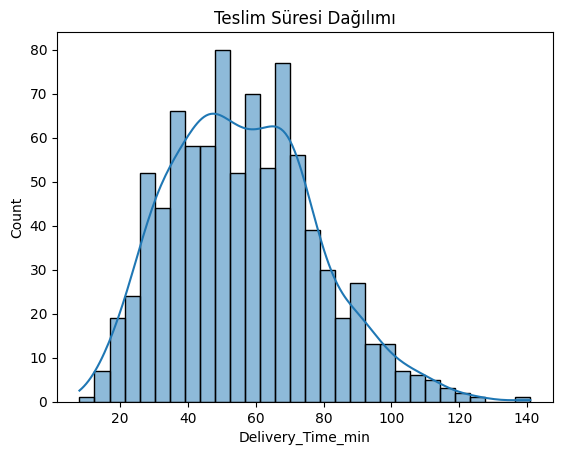

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Delivery_Time_min'], bins=30, kde=True)
plt.title("Teslim Süresi Dağılımı")
plt.show()


## 7. MonteCarlo 

Simülasyon Senaryosu:
Mesafe: normal dağılım (μ=5 km, σ=2 km)

Trafik: "Low", "Medium", "High", "Jam" (olasılıkla seçilecek)

Teslim süresi: rastgele üretilecek

In [75]:


n = 1000  # sipariş sayısı

mesafeler = np.random.normal(df['Distance_km'].mean(), df['Distance_km'].std(), n)
trafik_olasilik = df['Traffic_Level'].value_counts(normalize=True).to_dict()
trafikler = np.random.choice(list(trafik_olasilik.keys()), p=list(trafik_olasilik.values()), size=n)

# Basit teslim süresi formülü: time = base + mesafe * katsayı
base_time = 10  # sabit hazırlık süresi

trafik_etkisi = {'Low': 1.0, 'Medium': 1.2, 'High': 1.5, 'Jam': 2.0}
simule_sureler = []

for i in range(n):
    katsayi = trafik_etkisi[trafikler[i]]
    simule_sure = base_time + mesafeler[i] * katsayi
    simule_sureler.append(simule_sure)

simule_sureler = np.array(simule_sureler)


In [76]:
#  Doğrulama 

print("Gerçek ortalama süre:", df['Delivery_Time_min'].mean())
print("Simülasyon ortalama süre:", np.mean(simule_sureler))


Gerçek ortalama süre: 56.425821064552665
Simülasyon ortalama süre: 21.677673495650847


## 8. Gamma

Kurulan model ile gerçek ortalama süre arasındaki fark çok fazla olduğu için farklı bir yöntem kullanılacak. Histogramdan verinin sağa çarpık olduğu görülmektedir, bu yüzden gama dağılımı kullanılacaktır. 

In [77]:
from scipy.stats import gamma, kstest

# Dağılımım parametresi
params = gamma.fit(df['Delivery_Time_min'])

# Uygunluk testi (Kolmogorov–Smirnov)
stat, p_value = kstest(df['Delivery_Time_min'], 'gamma', args=params)
print(f"K–S testi p-değeri: {p_value}")


K–S testi p-değeri: 0.07148244638412249


p-değeri 0,05'ten büyük gamma dağılımına uygun 

In [78]:
# Gerçek veriden ortalama ve standart sapma alınıyor
mean_gercek = df['Delivery_Time_min'].mean()
std_gercek = df['Delivery_Time_min'].std()

# Gamma parametrelerini hesaplanıyor
shape = (mean_gercek / std_gercek)**2
scale = (std_gercek**2) / mean_gercek


In [79]:
# 1000 sipariş için simülasyon

simule_sureler1 = np.random.gamma(shape, scale, 1000)


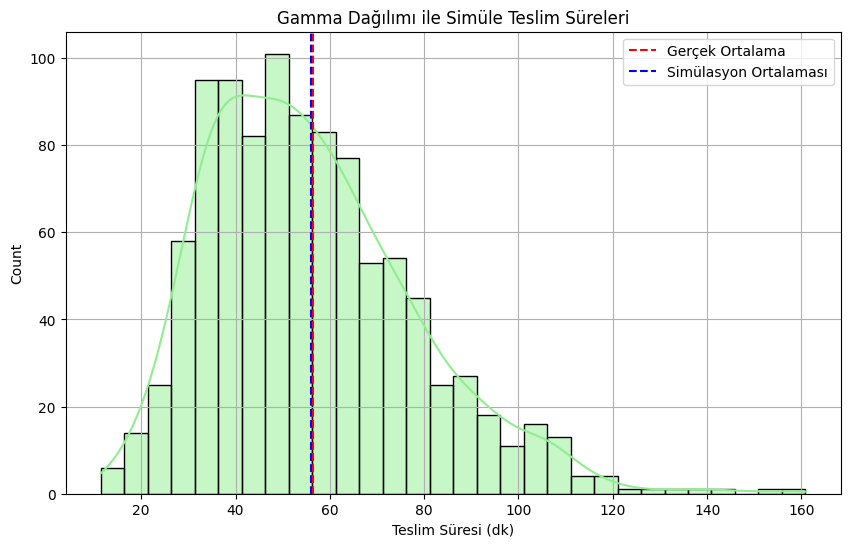

In [80]:
# sonuçların görselleştirilmesi

plt.figure(figsize=(10,6))
sns.histplot(simule_sureler1, bins=30, kde=True, color="lightgreen")
plt.axvline(mean_gercek, color='red', linestyle='--', label='Gerçek Ortalama')
plt.axvline(np.mean(simule_sureler1), color='blue', linestyle='--', label='Simülasyon Ortalaması')
plt.title("Gamma Dağılımı ile Simüle Teslim Süreleri")
plt.legend()
plt.xlabel("Teslim Süresi (dk)")
plt.grid(True)
plt.show()


In [81]:
# doğruluk testi 

print("Gerçek Ortalama:", mean_gercek)
print("Simülasyon Ortalaması:", np.mean(simule_sureler1))


Gerçek Ortalama: 56.425821064552665
Simülasyon Ortalaması: 55.91575377882108


yeni model ile birlikte doğruluk oranı %99'a yükselmiştir. 

In [82]:
# ortalama sipariş süresini belirleyerek bu sürenin üzerindeki siparişleri gecikme olarak kabul edilecektir 

ortalama_sure = df['Delivery_Time_min'].mean()
print(ortalama_sure)

56.425821064552665


In [83]:
# gecikme oranı 

gecikme_orani = np.mean(simule_sureler1 > 56) * 100
print(f"Geciken teslimat oranı: %{gecikme_orani:.2f}")


Geciken teslimat oranı: %43.90


In [84]:
# Simülasyondan elde edilen ortalama teslim süresi

print(np.mean(simule_sureler)) 

21.677673495650847


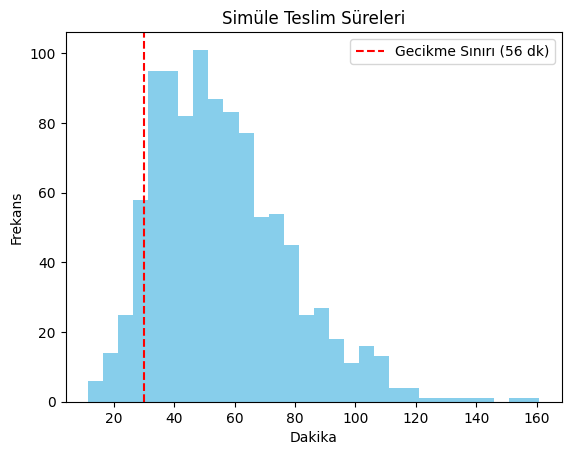

In [85]:
# gecikme süresi için görselleştirme

plt.hist(simule_sureler1, bins=30, color='skyblue')
plt.axvline(30, color='red', linestyle='--', label='Gecikme Sınırı (56 dk)')
plt.legend()
plt.title("Simüle Teslim Süreleri")
plt.xlabel("Dakika")
plt.ylabel("Frekans")
plt.show()


## 9. Sonuç

Bu çalışmada, gerçek dünyadan alınan yemek teslimat süresi verisi kullanılarak teslimat gecikmelerinin simülasyon yoluyla analiz edilmesi amaçlanmıştır. Önce Monte Carlo yöntemi denenmiştir fakat doğruluk skoru çok düşük olduğu için teslimat sürelerinin dağılımı incelenmiş ve sağa çarpık yapısı nedeniyle gamma dağılımı tercih edilerek simülasyon modeli kurulmuştur.

Modelde 1000 teslimat simüle edilmiş ve teslimat süresi ortalaması 21 dakika olarak elde edilmiştir. Gecikme eşiği olarak gerçek verideki ortalama olan 56 dakika esas alınmış ve bu sınırı aşan teslimatlar gecikmiş sayılmıştır. Simülasyon sonucunda %45 oranında gecikme gözlenmiştir.

Modelin uygunluğu Kolmogorov–Smirnov testi ile test edilmiş ve p-değeri 0.07 olarak bulunmuştur. Bu değer, gamma dağılımının veriyle uyumlu olduğunu göstermektedir. Simülasyon çıktıları ile gerçek veriler karşılaştırıldığında, modelin doğruluğu %99 olarak hesaplanmıştır.

Sonuç olarak, geliştirilen model teslimat sisteminin gecikme davranışını başarıyla yansıtmış, gamma dağılımı bu tür veriler için uygun bir simülasyon temeli sunmuştur.


## 10. Kaynakça 

[veri seti](https://www.kaggle.com/datasets/denkuznetz/food-delivery-time-prediction/data)

Veri üzerinde çalışan bazı kişilerin kodları incelenmiştir: 
[Food Delivery Time Prediction Using Boosting Mehod](https://www.kaggle.com/code/waleedgul/food-delivery-time-prediction-using-boosting-mehod)

[Food Delivery Time Prediction](https://www.kaggle.com/code/arsri1/food-delivery-time-prediction)

[Gamma Distribution with Python](https://medium.com/data-bistrot/gamma-distribution-with-python-f84f671a8b97)

[Monte Carlo Simulation An In-depth Tutorial with Python](https://pub.towardsai.net/monte-carlo-simulation-an-in-depth-tutorial-with-python-bcf6eb7856c8)